# LIAR Dataset Model Training

## Project Title
Algorithmic Fact-Verification Networks

## Objective
This notebook trains a simple machine learning model to classify news articles as True, Half True, Mostly True, Barely True or False using a LIAR Dataset.

## Model Approach
We use TF-IDF to convert text into numbers, then train a Logistic Regression model for binary classification though this dataset contained Multi-classes.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

## Read and Load Dataset

In [2]:
df = pd.read_csv("../data/liar_dataset/train.tsv",sep="\t",header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


## Inspect labels

In [3]:
df[1].value_counts()

1
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

## Create Binary Labels

In [4]:
label_mapping = {
    "true": 1,
    "mostly-true": 1,
    "half-true": 1,

    "false": 0,
    "barely-true": 0,
    "pants-fire": 0
}

df["label"] = df[1].map(label_mapping)

## Verify Mapping Worked

In [5]:
df["label"].value_counts()

label
1    5752
0    4488
Name: count, dtype: int64

## Rename Important Columns

In [6]:
df = df.rename(columns={
    1: "truth_label",
    2: "statement"
})

In [7]:
df[["statement", "truth_label", "label"]].head()

,statement,truth_label,label
0,Says the Annies List political group supports ...,false,0
1,When did the decline of coal start? It started...,half-true,1
2,"Hillary Clinton agrees with John McCain ""by vo...",mostly-true,1
3,Health care reform legislation is likely to ma...,false,0
4,The economic turnaround started at the end of ...,half-true,1


## Create x and y

In [8]:
X = df["statement"]
y = df["label"]

## Split Data into Training and Testing Sets

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8192
Testing samples: 2048


## Convert Text into Numbers (TF-IDF)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [12]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(8192, 5000)
(2048, 5000)


## Train Logistic Regression 

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Make Predictions

In [14]:
y_pred = model.predict(X_test_tfidf)

## Evaluate the Model

In [15]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.61474609375
Accuracy: 61.47%

Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.45      0.50       898
           1       0.63      0.75      0.69      1150

    accuracy                           0.61      2048
   macro avg       0.61      0.60      0.59      2048
weighted avg       0.61      0.61      0.61      2048



## Classification report

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.45      0.50       898
           1       0.63      0.75      0.69      1150

    accuracy                           0.61      2048
   macro avg       0.61      0.60      0.59      2048
weighted avg       0.61      0.61      0.61      2048



## Confusion matrix

In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[400 498]
 [291 859]]


## Test the Model With Custom Samples

In [18]:
sample_statements = [
    "The government announced a new policy to improve healthcare services.",
    "The president secretly received billions of dollars from foreign countries.",
    "Climate change is caused by human activities and scientific evidence supports this.",
    "A politician claimed that unemployment has completely disappeared."
]


sample_tfidf = tfidf.transform(sample_statements)

predictions = model.predict(sample_tfidf)

for statement, prediction in zip(sample_statements, predictions):
    result = "TRUE-ish" if prediction == 1 else "FALSE-ish"
    print("\nStatement:")
    print(statement)
    print("Prediction:", result)


Statement:
The government announced a new policy to improve healthcare services.
Prediction: FALSE-ish

Statement:
The president secretly received billions of dollars from foreign countries.
Prediction: FALSE-ish

Statement:
Climate change is caused by human activities and scientific evidence supports this.
Prediction: FALSE-ish

Statement:
A politician claimed that unemployment has completely disappeared.
Prediction: TRUE-ish


## Save the Model

In [22]:
joblib.dump(model, "../models/liar_dataset_model.pkl")
joblib.dump(tfidf,"../models/liar_dataset_tfidf.pkl")

['../models/liar_dataset_tfidf.pkl']

## PCA Visualization of Text Features

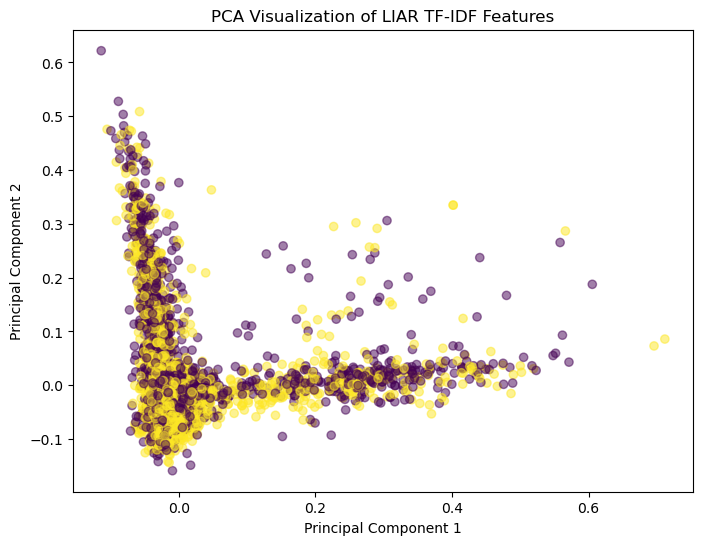

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# Convert sparse matrix to dense
X_dense = X_train_tfidf.toarray()

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_dense)


plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train,
    alpha=0.5
)

plt.title("PCA Visualization of LIAR TF-IDF Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()